# 02 — TSF Parser Validation

This notebook validates the reusable parser and dataset loader for Monash-style `.tsf` files from the Time Series PILE forecasting subset.

The goal is not to define the parser inside the notebook. The parser implementation is stored in `src/data/tsf_parser.py`, and this notebook checks that it works correctly on selected project datasets.

This notebook validates:

- metadata extraction,
- attribute parsing,
- conversion of time series values into structured records,
- missing-value handling,
- long-format conversion,
- chronological train-test split creation,
- loading of all final selected project datasets.

## 1. Setup

Import required libraries and add the project root to the Python path.

In [1]:
import os
import sys
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)
print("Imports loaded successfully.")

Project root: /Users/kunalgurung/Desktop/UTS SEM4/36127/timeseries-pile-foundation-model-benchmark
Imports loaded successfully.


## 2. Import parser and dataset loader

The parser and loader are imported from the reusable source modules. The notebook validates these functions instead of redefining parser logic inside the notebook.

In [2]:
from src.data.project_config import SELECTED_DATASETS
from src.data.dataset_loader import list_available_datasets, load_monash_dataset
from src.data.tsf_parser import (
    parse_tsf_file,
    convert_to_long_format,
    build_split_dataframe,
)

print("Parser and loader functions imported successfully.")

Parser and loader functions imported successfully.


## 3. Check dataset directory

This step checks whether `MONASH_TSF_BASE_DIR` is already set. If it is not set, the notebook downloads or reuses the cached Time Series PILE forecasting subset and sets the environment variable automatically.

In [4]:
from huggingface_hub import snapshot_download

monash_base_dir = os.environ.get("MONASH_TSF_BASE_DIR")

if monash_base_dir is None:
    print("MONASH_TSF_BASE_DIR is not set.")
    print("Downloading or reusing cached Time Series PILE forecasting subset...")

    local_snapshot_path = snapshot_download(
        repo_id="AutonLab/Timeseries-PILE",
        repo_type="dataset",
        allow_patterns=["forecasting/**"],
        max_workers=2,
    )

    monash_base_dir = Path(local_snapshot_path) / "forecasting" / "monash"
    os.environ["MONASH_TSF_BASE_DIR"] = str(monash_base_dir)

else:
    monash_base_dir = Path(monash_base_dir)

print("MONASH_TSF_BASE_DIR:")
print(os.environ["MONASH_TSF_BASE_DIR"])
print("Exists:", monash_base_dir.exists())

if not monash_base_dir.exists():
    raise FileNotFoundError(
        f"Monash TSF directory does not exist: {monash_base_dir}"
    )

/Users/kunalgurung/.pyenv/versions/3.11.4/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MONASH_TSF_BASE_DIR is not set.


Fetching ... files: 58it [00:00, 10368.22it/s]

MONASH_TSF_BASE_DIR:
/Users/kunalgurung/.cache/huggingface/hub/datasets--AutonLab--Timeseries-PILE/snapshots/ea89753da2b451928436adb333c7a2e892461c7d/forecasting/monash
Exists: True


## 4. List available datasets

Check that the loader can identify available `.tsf` datasets.

In [5]:
available_datasets = list_available_datasets()

print("Number of available datasets:", len(available_datasets))
print("First 20 dataset keys:")
print(available_datasets[:20])

Number of available datasets: 47
First 20 dataset keys:
['australian_electricity_demand', 'bitcoin', 'car_parts', 'cif_2016', 'covid_deaths', 'dominick', 'electricity_hourly', 'electricity_weekly', 'fred_md', 'hospital', 'kaggle_web_traffic', 'kaggle_web_traffic_weekly', 'kdd_cup_2018', 'london_smart_meters', 'm1_monthly', 'm1_quarterly', 'm1_yearly', 'm3_monthly', 'm3_other', 'm3_quarterly']


## 5. Select one dataset for parser validation

Use one selected project dataset as a parser sanity check.

In [6]:
dataset_key = "bitcoin"

print("Validation dataset:", dataset_key)
print("Dataset available:", dataset_key in available_datasets)

Validation dataset: bitcoin
Dataset available: True


## 6. Load dataset using the shared loader

The loader applies the TSF parser and returns structured dataset components used by downstream experiments. Frequency information is stored in the parsed metadata, while the normalized frequency is returned as a top-level field.

In [9]:
bundle = load_monash_dataset(dataset_key)

print("Loaded dataset bundle keys:")
pprint(list(bundle.keys()))

metadata = bundle["metadata"]

print("\nDataset metadata:")
print("Dataset key:", bundle["dataset_key"])
print("Domain:", bundle["domain"])
print("File name:", bundle["file_name"])
print("Original frequency:", metadata.get("frequency"))
print("Normalized frequency:", bundle["normalized_frequency"])
print("Resolved horizon:", bundle["resolved_horizon"])
print("Horizon strategy:", bundle["horizon_strategy"])

print("\nMetadata:")
pprint(metadata)

Loaded dataset bundle keys:
['dataset_key',
 'domain',
 'file_path',
 'file_name',
 'metadata',
 'attribute_defs',
 'records_df',
 'long_df',
 'split_df',
 'normalized_frequency',
 'resolved_horizon',
 'horizon_strategy']

Dataset metadata:
Dataset key: bitcoin
Domain: finance
File name: bitcoin.tsf
Original frequency: daily
Normalized frequency: daily
Resolved horizon: 30
Horizon strategy: fallback_capped

Metadata:
{'equallength': False,
 'frequency': 'daily',
 'missing': False,
 'relation': 'bitcoin_technological_factors'}


## 7. Inspect parsed records

Each row in `records_df` represents one time series from the `.tsf` file.

In [10]:
records_df = bundle["records_df"]

print("Records shape:", records_df.shape)
display(records_df.head())

print("Columns:")
print(records_df.columns.tolist())

Records shape: (18, 4)


,series_name,start_timestamp,series_values,series_length
0,difficulty,2009-01-03,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",4581
1,sent_addresses,2009-01-09,"[1.0, 1.0, 1.0, 7.0, 10.0, 20.0, 18.0, 16.0, 18.0, 16.0, 22.0, 21.0, 22.0, 12.0, 18.0, 22.0, 14.0, 17.0, 8.0, 23.0, 24.0, 23.0, 36.0, 31.0, 37.0, 50.0, 26.0, 34.0, 19.0, 32.0, 46.0, 34.0, 18.0, 27...",4575
2,send_usd,2010-07-17,"[1193.0, 2612.0, 4047.0, 2341.0, 2122.0, 2570.0, 1166.0, 2540.0, 2493.0, 4608.0, 1850.0, 4012.0, 1230.0, 1336.0, 1025.0, 16490.0, 3893.0, 2429.0, 2005.0, 2430.0, 1155.0, 1514.0, 616.346, 5060.0, 2...",4021
3,market_cap,2010-07-17,"[169839.0, 249761.0, 295981.0, 270546.0, 265900.0, 225420.0, 197086.0, 202929.0, 185609.0, 186308.0, 204589.0, 210197.0, 229629.0, 235363.0, 236589.0, 218064.0, 219511.0, 215757.0, 215175.0, 21553...",4021
4,confirmation_time,2009-01-09,"[102.857, 23.607, 15.484, 15.319, 11.707, 11.163, 11.429, 13.333, 13.211, 13.458, 12.522, 12.632, 14.118, 15.824, 17.143, 7.164, 7.539, 15.0, 14.845, 12.857, 11.901, 12.308, 10.435, 12.743, 11.25,...",4575


Columns:
['series_name', 'start_timestamp', 'series_values', 'series_length']


## 8. Inspect one parsed series

Check the first series values and length.

In [11]:
first_row = records_df.iloc[0]

series_values = first_row["series_values"]

print("Series ID:", first_row.get("series_name", "N/A"))
print("Series length:", len(series_values))
print("First 10 values:")
print(series_values[:10])
print("Missing values in first series:", pd.Series(series_values).isna().sum())

Series ID: difficulty
Series length: 4581
First 10 values:
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Missing values in first series: 0


## 9. Inspect long-format data

The long-format table stores one observation per row with `series_id`, time/step index, and value.

In [12]:
long_df = bundle["long_df"]

print("Long DataFrame shape:", long_df.shape)
display(long_df.head(20))

print("Number of unique series:", long_df["series_id"].nunique())
print("Number of missing values:", long_df["value"].isna().sum())

Long DataFrame shape: (75364, 4)


,series_id,timestamp,step_index,value
0,difficulty,2009-01-03,0,1.0
1,difficulty,2009-01-04,1,1.0
2,difficulty,2009-01-05,2,1.0
3,difficulty,2009-01-06,3,1.0
4,difficulty,2009-01-07,4,1.0
5,difficulty,2009-01-08,5,1.0
6,difficulty,2009-01-09,6,1.0
7,difficulty,2009-01-10,7,1.0
8,difficulty,2009-01-11,8,1.0
9,difficulty,2009-01-12,9,1.0


Number of unique series: 18
Number of missing values: 0


In [6]:
first_row = records_df.iloc[0].to_dict()

print("First parsed row:")
pprint({
    k: v if k != "series_values" else v[:10]
    for k, v in first_row.items()
})

print("\nFirst series length:", len(records_df.iloc[0]["series_values"]))

First parsed row:
{'series_length': 20,
 'series_name': 'T1',
 'series_values': [940.66,
                   1084.86,
                   1244.98,
                   1445.02,
                   1683.17,
                   2038.15,
                   2342.52,
                   2602.45,
                   2927.87,
                   3103.96],
 'start_timestamp': Timestamp('1975-01-01 00:00:00')}

First series length: 20


## 10. Plot a sample series

Visualise one parsed time series to confirm that values were loaded correctly.

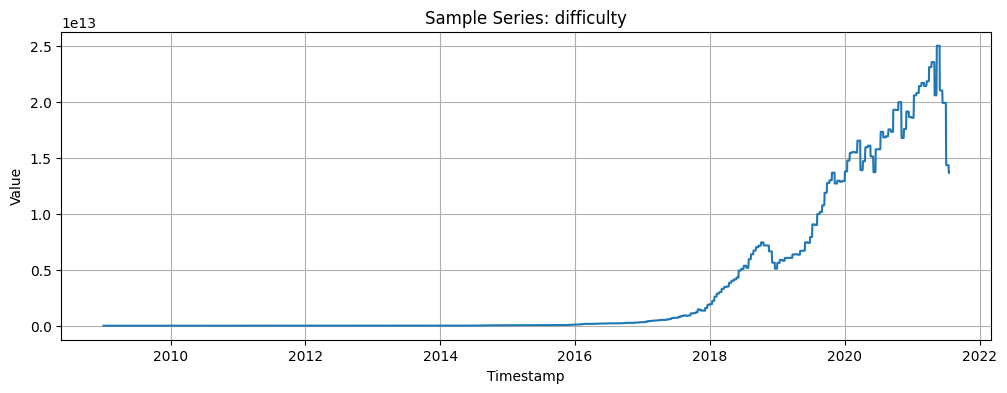

In [13]:
sample_series_id = long_df["series_id"].dropna().unique()[0]
sample_series_df = long_df[long_df["series_id"] == sample_series_id].copy()

plt.figure(figsize=(12, 4))

if "timestamp" in sample_series_df.columns and sample_series_df["timestamp"].notna().any():
    plt.plot(sample_series_df["timestamp"], sample_series_df["value"])
    plt.xlabel("Timestamp")
else:
    plt.plot(sample_series_df["step_index"], sample_series_df["value"])
    plt.xlabel("Step Index")

plt.ylabel("Value")
plt.title(f"Sample Series: {sample_series_id}")
plt.grid(True)
plt.show()

## 11. Inspect train-test split

The dataset loader creates chronological train-test splits using the resolved forecasting horizon.

In [14]:
split_df = bundle["split_df"]

print("Split DataFrame shape:", split_df.shape)
display(split_df.head())

first_split = split_df.iloc[0]

print("Series ID:", first_split["series_id"])
print("Train length:", len(first_split["train_values"]))
print("Test length:", len(first_split["test_values"]))
print("Resolved horizon:", bundle["resolved_horizon"])

Split DataFrame shape: (18, 5)


,series_id,train_values,test_values,train_length,test_length
0,difficulty,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[19932791027263.0, 19932791027263.0, 19932791027263.0, 19932791027263.0, 19932791027263.0, 19932791027263.0, 19932791027263.0, 19932791027263.0, 19932791027263.0, 19932791027263.0, 19932791027263....",4551,30
1,sent_addresses,"[1.0, 1.0, 1.0, 7.0, 10.0, 20.0, 18.0, 16.0, 18.0, 16.0, 22.0, 21.0, 22.0, 12.0, 18.0, 22.0, 14.0, 17.0, 8.0, 23.0, 24.0, 23.0, 36.0, 31.0, 37.0, 50.0, 26.0, 34.0, 19.0, 32.0, 46.0, 34.0, 18.0, 27...","[308785.0, 384401.0, 385925.0, 419947.0, 411788.0, 391933.0, 324459.0, 255643.0, 425476.0, 411674.0, 416484.0, 461838.0, 392516.0, 412124.0, 329197.0, 394868.0, 427151.0, 423969.0, 430843.0, 43006...",4545,30
2,send_usd,"[1193.0, 2612.0, 4047.0, 2341.0, 2122.0, 2570.0, 1166.0, 2540.0, 2493.0, 4608.0, 1850.0, 4012.0, 1230.0, 1336.0, 1025.0, 16490.0, 3893.0, 2429.0, 2005.0, 2430.0, 1155.0, 1514.0, 616.346, 5060.0, 2...","[10990052410.0, 21036373250.0, 24660356338.0, 21319509002.0, 21994140039.0, 32555007021.0, 25062597251.0, 13797785546.0, 18763855073.0, 19715504596.0, 18186919492.0, 17750818544.0, 19384762039.0, ...",3991,30
3,market_cap,"[169839.0, 249761.0, 295981.0, 270546.0, 265900.0, 225420.0, 197086.0, 202929.0, 185609.0, 186308.0, 204589.0, 210197.0, 229629.0, 235363.0, 236589.0, 218064.0, 219511.0, 215757.0, 215175.0, 21553...","[657384614358.0, 621724070499.0, 599911100740.0, 632425086864.0, 632484258208.0, 625547023191.0, 590174775638.0, 619794797592.0, 646150411692.0, 666249595423.0, 654769452314.0, 632314327003.0, 623...",3991,30
4,confirmation_time,"[102.857, 23.607, 15.484, 15.319, 11.707, 11.163, 11.429, 13.333, 13.211, 13.458, 12.522, 12.632, 14.118, 15.824, 17.143, 7.164, 7.539, 15.0, 14.845, 12.857, 11.901, 12.308, 10.435, 12.743, 11.25,...","[13.714, 13.714, 15.824, 14.257, 13.714, 13.091, 16.18, 24.828, 16.364, 16.0, 16.364, 15.0, 16.0, 11.339, 12.522, 10.909, 10.141, 11.707, 10.36, 10.992, 8.944, 11.52, 11.429, 10.588, 8.471, 11.25,...",4545,30


Series ID: difficulty
Train length: 4551
Test length: 30
Resolved horizon: 30


## 12. Validate all selected project datasets

Load all final selected datasets to confirm that the parser and loader work across finance, energy, and retail datasets.

In [15]:
validation_rows = []

for dataset_key in SELECTED_DATASETS:
    try:
        bundle = load_monash_dataset(dataset_key)

        validation_rows.append(
            {
                "dataset_key": dataset_key,
                "domain": bundle["domain"],
                "frequency": bundle["normalized_frequency"],
                "horizon": bundle["resolved_horizon"],
                "horizon_strategy": bundle["horizon_strategy"],
                "n_records": len(bundle["records_df"]),
                "n_split_series": len(bundle["split_df"]),
                "status": "success",
                "error_message": None,
            }
        )

    except Exception as error:
        validation_rows.append(
            {
                "dataset_key": dataset_key,
                "domain": None,
                "frequency": None,
                "horizon": None,
                "horizon_strategy": None,
                "n_records": None,
                "n_split_series": None,
                "status": "failed",
                "error_message": str(error),
            }
        )

validation_df = pd.DataFrame(validation_rows)

display(validation_df)
print(validation_df["status"].value_counts())

,dataset_key,domain,frequency,horizon,horizon_strategy,n_records,n_split_series,status,error_message
0,bitcoin,finance,daily,30,fallback_capped,18,18,success,None
1,fred_md,finance,monthly,24,fallback_capped,107,107,success,None
2,m1_monthly,finance,monthly,18,metadata,617,617,success,None
3,solar_weekly,energy,weekly,5,metadata,137,137,success,None
4,saugeenday,energy,daily,30,fallback_capped,1,1,success,None
5,electricity_weekly,energy,weekly,8,metadata,321,321,success,None
6,car_parts,retail,monthly,5,fallback_capped,2674,2674,success,None
7,nn5_weekly,retail,weekly,8,metadata,111,111,success,None
8,nn5_daily,retail,daily,56,metadata,111,111,success,None


status
success    9
Name: count, dtype: int64


## 13. Validation summary

Summarise whether the parser and dataset loader are ready for downstream experiments.

In [16]:
all_successful = (validation_df["status"] == "success").all()

summary = {
    "validation_dataset": "bitcoin",
    "selected_datasets_checked": len(validation_df),
    "all_selected_datasets_loaded": all_successful,
    "failed_datasets": validation_df.loc[
        validation_df["status"] != "success", "dataset_key"
    ].tolist(),
}

pprint(summary)

{'all_selected_datasets_loaded': np.True_,
 'failed_datasets': [],
 'selected_datasets_checked': 9,
 'validation_dataset': 'bitcoin'}


## Validation conclusion

The TSF parser and shared dataset loader successfully convert Monash-style `.tsf` files into structured records, long-format data, and chronological train-test splits.

This validation confirms that the selected project datasets can be loaded consistently before running the benchmark experiment notebooks.